In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors


from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from collections import Counter
from tqdm.notebook import tqdm
from deeptime.clustering import KMeans
from deeptime.clustering import RegularSpace
from deeptime.clustering import BoxDiscretization
import pandas as pd 
import pyemma

import mdtraj as md
import re, math, os, shutil, pickle

import warnings; warnings.simplefilter('ignore')
from collections import Counter

## Important Functions

In [10]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)

In [11]:
# Define the directory path
directory = "clustering/"

remove_and_clean = True

# Check if the directory exists
if os.path.exists(directory):
    if remove_and_clean:
        # Remove all contents of the directory
        shutil.rmtree(directory)
        # Recreate the empty directory
        os.makedirs(directory)
        print(f"All contents in '{directory}' have been cleared.")
    else:
        print(f"Directory '{directory}' already exists. No action taken.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

All contents in 'clustering/' have been cleared.


## Load the data

In [12]:
## Load Distance Restraubt Data 
dist_path = f"traj_data/dist_state0.pkl"
dist = Data.load(dist_path)
dist = dist.array_list
print(f'dist.shape:{np.array(dist).shape}')

## Load Backbone Phi Omega angle 
omega_path = f"traj_data/omegas_state0.pkl"
omegas = Data.load(omega_path)
omegas = omegas.array_list
print(f'omegas.shape: {np.array(omegas).shape}')

residues_to_plot = np.arange(0, 24, 4).tolist()  # Modify if needed

omega_indices = [r for r in residues_to_plot]
phi_indices   = [r + 1 for r in residues_to_plot]
psi_indices   = [r + 2 for r in residues_to_plot]
chi1_indices  = [r + 3 for r in residues_to_plot]

for angle_indices in [omega_indices, psi_indices, chi1_indices]:
    omegas[:, angle_indices] = (omegas[:, angle_indices] + 90.0) % 360.0 - 90.0

feat_all = np.hstack([dist,omegas])
print('feat_all.shape', feat_all.shape)

dist.shape:(200010, 76)
omegas.shape: (200010, 24)
feat_all.shape (200010, 100)


## Clustering with Selected Backbone Angle 

In [13]:
residues_to_plot = np.arange(0, 24, 4).tolist()  # [0, 4, 8, 12, 16, 20]
omega_features = feat_all[:, -24:]              # Get the last 24 columns
selected_omegas = omega_features[:, residues_to_plot]
selected_phi = omega_features[:, [i + 1 for i in residues_to_plot]]
selected_psi = omega_features[:, [i + 2 for i in residues_to_plot]]
selected_khi = omega_features[:, [i + 3 for i in residues_to_plot]]

In [14]:
omega_binary = (selected_omegas > 90).astype(int)  # 1 if > 90, else 0
phi_binary = (selected_phi > 0).astype(int)        # 1 if > 0, else 0


In [15]:
backbone_signature = np.hstack([omega_binary, phi_binary])  # shape (200010, 12)
backbone_signature.shape

(200010, 12)

In [16]:
# Convert each row to a tuple so they are hashable
signatures = [tuple(row) for row in backbone_signature]

# Map to integer labels
df_signatures = pd.DataFrame(signatures, columns=[f"f{i}" for i in range(12)])
df_signatures["cluster_label"] = pd.factorize(signatures)[0]  # returns labels 0, 1, 2, ...

# Final cluster labels:
assignments = df_signatures["cluster_label"].to_numpy()

assignments.shape

(200010,)

In [17]:
# count the number of each cluter 
counts = Counter(assignments)
#print(counts)

# Sort the counts 
sorted_counts = dict(sorted(counts.items()))
total_counts = sum(counts.values())
cluster = []

# Create a DataFrame to hold results
data = {
    "Cluster Label": [],
    "Count": [],
    "Population": []
}

for label, frequency in sorted_counts.items():    
    percentage = (frequency / total_counts) * 100 
    data["Cluster Label"].append(label)
    data["Count"].append(frequency)
    data["Population"].append(round(percentage, 4))  # round for cleaner display
    #print(f"Assignment {label}: {frequency}, {percentage:.4g}%")

# Convert to DataFrame
df_cluster = pd.DataFrame(data)

# Save to CSV
df_cluster.to_csv("clustering/cluster_percentages.csv", index=False)
df_cluster

,Cluster Label,Count,Population
0,0,5758,2.8789
1,1,590,0.2950
2,2,41,0.0205
3,3,364,0.1820
4,4,278,0.1390
...,...,...,...
87,87,1,0.0005
88,88,53,0.0265
89,89,144,0.0720
90,90,680,0.3400


## Analysis Top Labels

In [18]:
# Example input (either form)
#top_n = 5                     # automatic selection
# top_n = [2, 5, 7]              # manual selection
top_n = [ 9,  7,  0, 10, 15]                  # manually selected cluster 10

# Process top clusters
if isinstance(top_n, int):
    # Automatically choose top-N most populated clusters
    top = sorted(sorted_counts.items(), key=lambda x: x[1], reverse=True)[:top_n]
elif isinstance(top_n, list):
    # Manually specified cluster labels
    top = [(label, sorted_counts[label]) for label in top_n if label in sorted_counts]
else:
    raise ValueError("top_n must be either an int or a list of cluster labels.")


print(f"Top {top_n} most populated clusters:")
for label, count in top:
    percentage = (count / total_counts) * 100
    print(f"Assignment {label}: {count} frames, {percentage:.4g}%")


Top [9, 7, 0, 10, 15] most populated clusters:
Assignment 9: 24211 frames, 12.1%
Assignment 7: 5054 frames, 2.527%
Assignment 0: 5758 frames, 2.879%
Assignment 10: 2031 frames, 1.015%
Assignment 15: 35670 frames, 17.83%


In [19]:
top_cluster = {label: [] for label in top_n}

for label in top_cluster:
    indices = np.where(assignments == label)[0]  # These are the frame indices
    top_cluster[label] = indices  # Just store the indices directly
    # Print label and first few indices
    example_indices = indices[:5]  # first 5 indices
    print(f"Cluster {label}: {len(indices)} frames — example indices: {example_indices}")


Cluster 9: 24211 frames — example indices: [3174 3371 3373 3374 3380]
Cluster 7: 5054 frames — example indices: [1082 1083 1085 1086 1087]
Cluster 0: 5758 frames — example indices: [0 1 2 3 4]
Cluster 10: 2031 frames — example indices: [3644 3667 3668 3671 3672]
Cluster 15: 35670 frames — example indices: [4980 4989 4992 4993 5009]


## Analysis the Ensembles

In [20]:
## cluster with indices 

cluster = {label: [] for label in np.unique(assignments)}

for label in cluster:
    indices = np.where(assignments == label)[0]  # These are the frame indices
    cluster[label] = indices  # Just store the indices directly

# Find the cluster with the fewest frames
min_label, min_size = min(((label, len(frames)) for label, frames in cluster.items()), key=lambda x: x[1])
print(f"Cluster {min_label} has the fewest frames: {min_size}")


Cluster 73 has the fewest frames: 1


In [21]:
cluster_frame_dist = {}

for label in tqdm(np.unique(assignments)):
    data = []
    for idx in cluster[label]:  # idx is the frame index
        dist_row = dist[idx] 
        data.append((idx, dist_row))
    cluster_frame_dist[label] = data


  0%|          | 0/92 [00:00<?, ?it/s]

In [22]:
sample_size = 50
np.random.seed(42)  # For reproducibility

sampled_distances = {label: [] for label in np.unique(assignments)}

for label, items in tqdm(cluster_frame_dist.items()):
    cluster_size = len(items)

    # Use the smaller of sample_size or cluster_size
    current_sample_size = min(sample_size, cluster_size)
    
    if current_sample_size < sample_size:
        print(f"Cluster {label} has only {cluster_size} items — sampling {current_sample_size} instead of {sample_size}")

    # Randomly sample indices
    sampled_indices = np.random.choice(cluster_size, current_sample_size, replace=False)

    # Extract sampled distance rows only
    sampled = [items[i] for i in sampled_indices]  # (idx, dist_row)
    sampled_distances[label] = np.array([dist for (_, dist) in sampled])


  0%|          | 0/92 [00:00<?, ?it/s]

Cluster 2 has only 41 items — sampling 41 instead of 50
Cluster 11 has only 12 items — sampling 12 instead of 50
Cluster 30 has only 40 items — sampling 40 instead of 50
Cluster 32 has only 37 items — sampling 37 instead of 50
Cluster 36 has only 20 items — sampling 20 instead of 50
Cluster 38 has only 39 items — sampling 39 instead of 50
Cluster 44 has only 15 items — sampling 15 instead of 50
Cluster 46 has only 24 items — sampling 24 instead of 50
Cluster 47 has only 2 items — sampling 2 instead of 50
Cluster 49 has only 18 items — sampling 18 instead of 50
Cluster 50 has only 31 items — sampling 31 instead of 50
Cluster 51 has only 28 items — sampling 28 instead of 50
Cluster 55 has only 24 items — sampling 24 instead of 50
Cluster 60 has only 7 items — sampling 7 instead of 50
Cluster 61 has only 47 items — sampling 47 instead of 50
Cluster 63 has only 31 items — sampling 31 instead of 50
Cluster 64 has only 16 items — sampling 16 instead of 50
Cluster 66 has only 49 items — sampl

In [23]:
### Calculate the average distance of each clusters  

average_distances = {} ## Create (n_cluster, ave_dist)
cluster_average_dist = []

for label, dist_array in tqdm(sampled_distances.items()):
    # dist_array: shape (sample_size, 76)
    avg_dist = dist_array.mean(axis=0)  # average across samples → shape (76,)
    average_distances[label] = avg_dist
    cluster_average_dist.append(avg_dist)

# Convert to DataFrame saving for biceps 
df_MD_dist = pd.DataFrame(cluster_average_dist)

# Save to CSV
df_MD_dist.to_csv("clustering/md_distances.csv", index=False)
df_MD_dist


  0%|          | 0/92 [00:00<?, ?it/s]

,0,1,2,3,4,5,6,7,8,9,...,66,67,68,69,70,71,72,73,74,75
0,3.462405,3.712730,3.705299,3.910542,3.031097,3.358095,4.461123,4.875912,4.472807,4.445637,...,4.504618,3.821012,4.577185,3.768358,4.824620,4.196976,4.877058,4.204907,4.908937,4.235496
1,3.590082,3.526355,3.535192,3.519043,3.642625,3.613061,4.585789,4.508543,7.001616,7.014586,...,4.180479,3.446177,4.306064,3.574526,5.071626,4.404196,4.929969,4.298748,5.055478,4.349982
2,3.138313,2.977119,3.643166,3.584194,3.610813,3.538872,4.510716,4.352801,8.826521,8.851707,...,4.894354,4.189025,4.987405,4.358183,4.946786,4.405647,5.091437,4.507504,5.038699,4.480947
3,3.225114,3.670859,2.963907,3.505973,4.297383,4.485794,4.342130,4.691360,8.680746,9.221660,...,3.093875,4.310979,3.266774,4.433865,4.811749,4.118772,4.845133,4.203849,4.817731,4.141056
4,3.548154,3.656920,3.668005,3.749060,4.352550,4.403308,3.573124,3.632864,9.407414,9.346110,...,4.334373,3.541246,4.147141,3.486184,3.913639,4.693165,3.815014,4.461913,3.790664,4.639440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,3.423229,4.122172,3.511211,4.216089,4.703213,5.831759,3.538673,4.419096,9.101638,8.601164,...,3.414292,4.458136,4.416524,5.314421,4.716291,4.677041,5.543022,4.929565,5.257783,5.089931
88,3.356150,3.881668,3.213852,3.825318,4.006694,4.808483,3.281886,3.742742,5.672575,5.752403,...,2.744710,4.145931,3.169309,4.355810,3.368176,4.583436,3.106428,4.371544,3.202417,4.403015
89,3.340997,3.465961,3.025237,3.111193,4.684990,4.793496,4.768429,4.881761,8.428474,8.542808,...,3.054224,4.409333,2.836263,4.212044,4.874549,4.333124,4.991827,4.327507,5.074786,4.462917
90,3.666662,3.491201,3.729722,3.495494,4.278071,4.090952,3.785676,3.586740,9.014377,8.693408,...,4.574163,3.729890,4.441291,3.699718,3.169811,4.347027,3.365519,4.508635,3.213848,4.358820


In [24]:

### Creat a list to store for each 76 distance, store the average value of those cluster (dist, n_cluster)
average_distances_list = []

# Get sorted list of labels
cluster_labels = sorted(average_distances.keys())  # e.g., [0, 1, 2, ..., 499]
n_clusters = len(cluster_labels)

# Initialize a matrix: rows = 76 distances, cols = cluster labels
average_distances_array = np.zeros((76, n_clusters))

for j, label in enumerate(cluster_labels):  # j = column index
    average_distances_array[:, j] = average_distances[label]  # shape (76,)



## Refer NMR Labels

In [25]:
restraints_table = {
    'weak': 5,
    'medium': 3.5,
    'strong': 2.5
}

dist_res_file = '../../../utils/nspe_7_1_restraints.csv'
df_dist_res = pd.read_csv(dist_res_file)

for i, row in df_dist_res.iterrows():
    df_dist_res.at[i, df_dist_res.columns[2]] = restraints_table[row[2]]  # Correct mapping

# Make a look up table for intensity 
df_dist_res
dist_res = df_dist_res.values.tolist()
dist_res[:5]

[[160, 165, 5], [160, 166, 5], [161, 165, 5], [161, 166, 5], [137, 165, 5]]

In [26]:
atomtype_lookup = {
    ('H02', 'H12'): 'α11',
    ('H02', 'H13'): 'α11',
    ('H02', 'H3'): 'α2',
    ('H02', 'H4'): 'β3',
    ('H02', 'H5'): 'β3',
    ('H02', 'H6'): 'β3',
    ('R02', 'H10'): 'α11',
    ('R02', 'H11'): 'α11',
    ('R02', 'H1'): 'α2',
    ('R02', 'H2'): 'β3',
    ('R02', 'H3'): 'β3',
    ('R02', 'H4'): 'β3',
    ('NH2', 'HN1'): 'NH1',
    ('NH2', 'HN2'): 'NH1',
}


In [27]:
def translate_pyemma_label(label):
    # Remove 'DIST: ' prefix and whitespace
    label = label.replace('DIST: ', '').strip()
    
    # Split into two atoms
    part1, part2 = label.split(' - ')
    resname1, resid1, atomname1, atomid1 = part1.split()
    resname2, resid2, atomname2, atomid2 = part2.split()

    # Lookup group for each atom
    group1 = atomtype_lookup.get((resname1, atomname1), 'unknown')
    group2 = atomtype_lookup.get((resname2, atomname2), 'unknown')

    # Print (optional)
    print(f"Label: {label}")
    print(f"Residue 1: {resname1} {resid1}, Atom: {atomname1} ({atomid1}), Group: {group1}")
    print(f"Residue 2: {resname2} {resid2}, Atom: {atomname2} ({atomid2}), Group: {group2}")

    # Return formatted result
    return f"{resid1}{group1}-{resid2}{group2}"


In [28]:
# Settings
human_interpretable_label = True
grofile = "../nspe_7_1.amb2gmx/nspe_7_1_GMX.gro"

# Prepare label cache
labels = []
targets = []

for atom1, atom2, target in dist_res:
    targets.append(target)

    atom1_pyemma = atom1 - 1
    atom2_pyemma = atom2 - 1
    feat = pyemma.coordinates.featurizer(grofile)
    feat.add_distances([[atom1_pyemma, atom2_pyemma]])
    raw_label = feat.describe()[0]

    if human_interpretable_label:
        label = translate_pyemma_label(label=raw_label)
    else:
        label = raw_label

    labels.append(label)

targets = np.array(targets)
labels


Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

['7α11-8NH1',
 '7α11-8NH1',
 '7α11-8NH1',
 '7α11-8NH1',
 '6α11-8NH1',
 '6α11-8NH1',
 '6α11-8NH1',
 '6α11-8NH1',
 '3α11-8NH1',
 '3α11-8NH1',
 '3α11-8NH1',
 '3α11-8NH1',
 '7α11-7α2',
 '7α11-7α2',
 '3α11-3α2',
 '3α11-3α2',
 '2α11-2α2',
 '2α11-2α2',
 '5β3-4α11',
 '5β3-4α11',
 '5β3-4α11',
 '5β3-4α11',
 '5β3-4α11',
 '5β3-4α11',
 '4α11-5α2',
 '4α11-5α2',
 '5α11-6α2',
 '5α11-6α2',
 '4α11-3α11',
 '4α11-3α11',
 '4α11-3α11',
 '4α11-3α11',
 '6β3-5α11',
 '6β3-5α11',
 '6β3-5α11',
 '6β3-5α11',
 '6β3-5α11',
 '6β3-5α11',
 '6α11-7α11',
 '6α11-7α11',
 '6α11-7α11',
 '6α11-7α11',
 '7α11-6α11',
 '7α11-6α11',
 '7α11-6α11',
 '7α11-6α11',
 '2β3-2α11',
 '2β3-2α11',
 '2β3-2α11',
 '2β3-2α11',
 '2β3-2α11',
 '2β3-2α11',
 '3α11-2α11',
 '3α11-2α11',
 '3α11-2α11',
 '3α11-2α11',
 '3β3-3α11',
 '3β3-3α11',
 '3β3-3α11',
 '3β3-3α11',
 '3β3-3α11',
 '3β3-3α11',
 '1α11-2α2',
 '1α11-2α2',
 '6β3-6α11',
 '6β3-6α11',
 '6β3-6α11',
 '6β3-6α11',
 '6β3-6α11',
 '6β3-6α11',
 '7β3-7α11',
 '7β3-7α11',
 '7β3-7α11',
 '7β3-7α11',
 '7β3-7α11

In [29]:
 
df_labels = pd.DataFrame(labels)
df_labels.to_csv("clustering/human_readable_labels.csv", index=False)
df_labels


,0
0,7α11-8NH1
1,7α11-8NH1
2,7α11-8NH1
3,7α11-8NH1
4,6α11-8NH1
...,...
71,7β3-7α11
72,7β3-7α11
73,7β3-7α11
74,7β3-7α11


## Plot Ensembles Distances

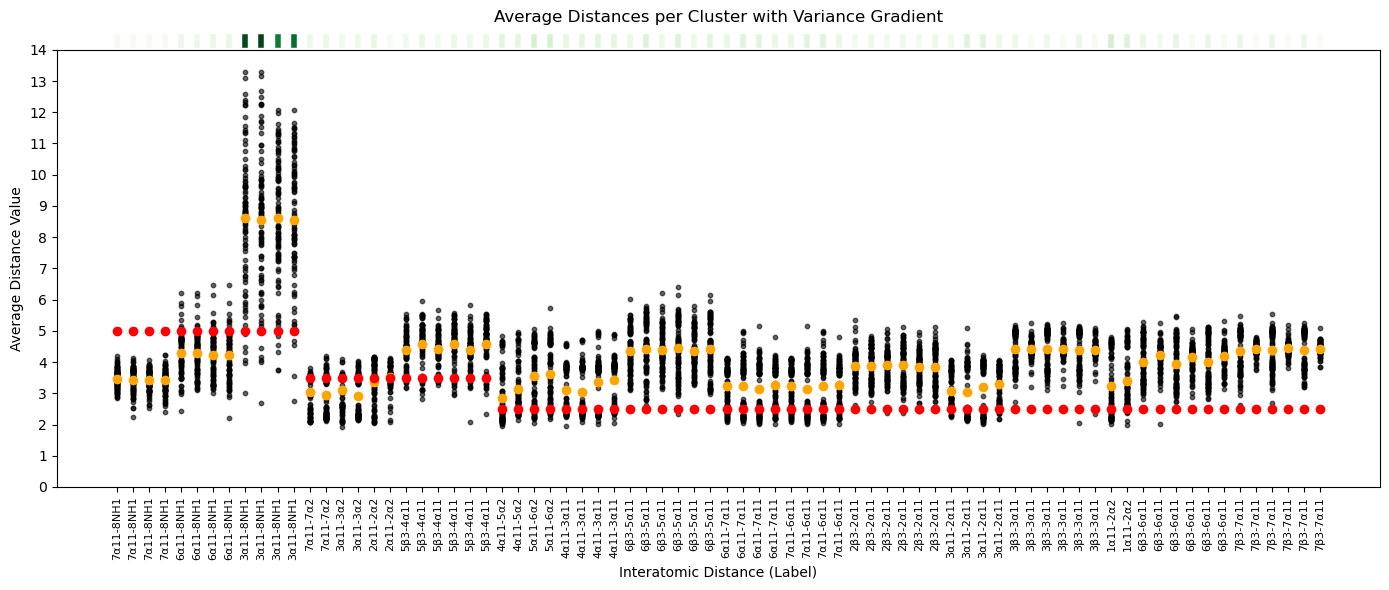

In [31]:
mean_across_clusters = average_distances_array.mean(axis=1)     # shape (76,)
var_across_clusters = average_distances_array.var(axis=1)       # shape (76,)
# Normalize the variance values to 0–1 for colormap
norm = mcolors.Normalize(vmin=var_across_clusters.min(), vmax=var_across_clusters.max())
cmap = cm.Greens  # or another colormap
colors = cmap(norm(var_across_clusters))  # shape: (76, 4) — RGBA colors


plt.figure(figsize=(14, 6))


# Scatter plot: one color per cluster
for j, label_id in enumerate(cluster_labels):
    plt.scatter(range(76), average_distances_array[:, j], color='black',
            s=10, alpha=0.6)
plt.scatter(range(76), mean_across_clusters, color='orange')
plt.scatter(range(76), targets, color='red')
for i in range(76):
    plt.axvline(x=i, ymin=1.01, ymax=1.03, color=colors[i], linewidth=4, clip_on=False)


# X-axis ticks as human-readable labels
plt.xticks(ticks=np.arange(76), labels=labels, rotation=90, fontsize=8)
plt.yticks(ticks=np.arange(0, plt.ylim()[1] + 1, 1))  # interval = 1
plt.xlabel("Interatomic Distance (Label)")
plt.ylabel("Average Distance Value")
plt.title("Average Distances per Cluster with Variance Gradient", pad=20)
plt.tight_layout()
plt.show()


In [32]:
average_distances_array_T = average_distances_array.T 
print('average_distances_array_T.shape', average_distances_array_T.shape)

rmsd = np.sqrt(np.mean((average_distances_array_T - targets) ** 2, axis=1))
rmsd.shape



average_distances_array_T.shape (92, 76)


(92,)

In [41]:
# Get indices of clusters sorted by RMSD
sorted_indices = np.argsort(rmsd)

# Get the smallest five
top5_indices = sorted_indices[:5]
top5_indices = np.array([ 9,  7,  0, 10, 15])
top5_indices = np.array([ 9])
top5_rmsd = rmsd[top5_indices]

# Print them
for rank, (idx, val) in enumerate(zip(top5_indices, top5_rmsd), 1):
    print(f"{rank}. Cluster {idx} → RMSD = {val:.4f}")

top5_indices


1. Cluster 9 → RMSD = 1.2684


array([9])

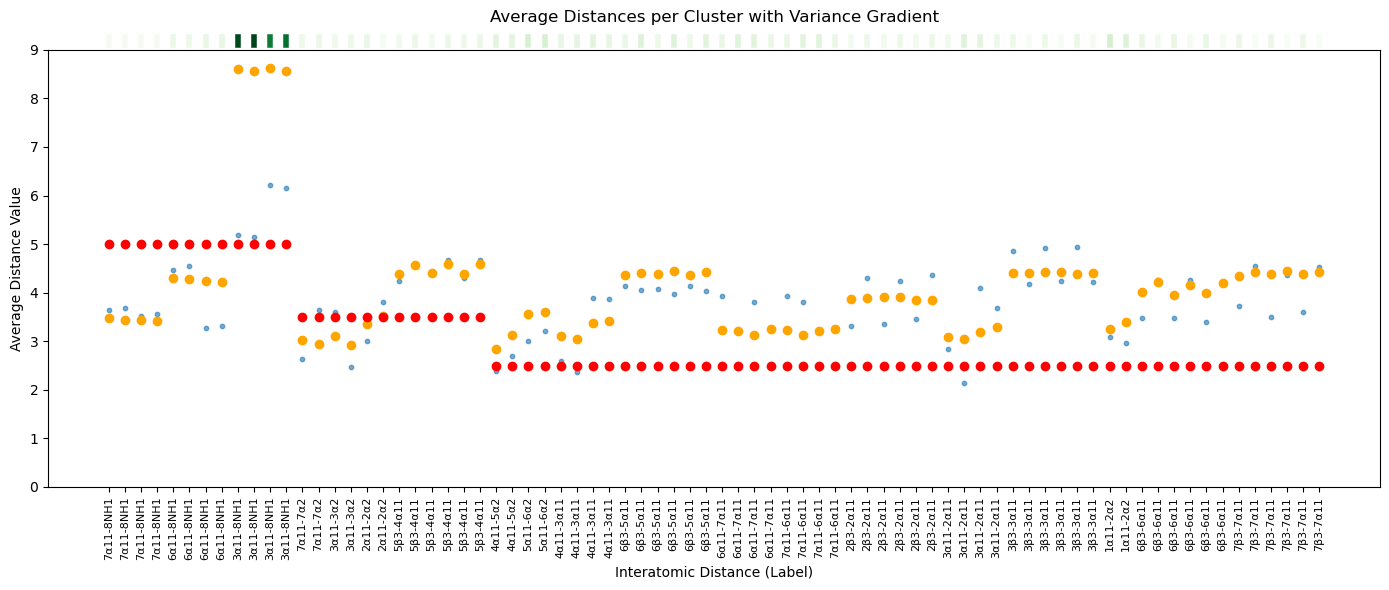

In [42]:
mean_across_clusters = average_distances_array.mean(axis=1)     # shape (76,)
var_across_clusters = average_distances_array.var(axis=1)       # shape (76,)
# Normalize the variance values to 0–1 for colormap
norm = mcolors.Normalize(vmin=var_across_clusters.min(), vmax=var_across_clusters.max())
cmap = cm.Greens  # or another colormap
colors = cmap(norm(var_across_clusters))  # shape: (76, 4) — RGBA colors


plt.figure(figsize=(14, 6))


# Only plot top 5 lowest-RMSD clusters
for cluster_idx in top5_indices:
    plt.scatter(range(76), average_distances_array_T[cluster_idx], 
                s=10, alpha=0.6, label=f'Cluster {cluster_idx}')
plt.scatter(range(76), mean_across_clusters, color='orange')
plt.scatter(range(76), targets, color='red')
for i in range(76):
    plt.axvline(x=i, ymin=1.01, ymax=1.03, color=colors[i], linewidth=4, clip_on=False)


# X-axis ticks as human-readable labels
plt.xticks(ticks=np.arange(76), labels=labels, rotation=90, fontsize=8)
plt.yticks(ticks=np.arange(0, plt.ylim()[1] + 1, 1))  # interval = 1
plt.xlabel("Interatomic Distance (Label)")
plt.ylabel("Average Distance Value")
plt.title("Average Distances per Cluster with Variance Gradient", pad=20)
plt.tight_layout()
plt.show()


## Analysis Dihedral

In [36]:
def plot_dihedral_quadruplets(
    omega_all,
    residues_to_plot,
    states=range(16),
    use_latex=True,
    angles_to_plot=None
):
    """
    Plot selected dihedral angle pairs for each residue in each state.

    Parameters:
    -----------
    omega_all : np.ndarray
        Shape (n_states, n_frames, n_dihedrals)
    residues_to_plot : list of int
        Starting indices of each residue block (omega, phi, psi, chi1)
    states : list
        Indices of states to plot
    use_latex : bool
        Use LaTeX formatting for labels
    angles_to_plot : list of str
        Angle pairs to plot. Options:
            'omega_phi', 'omega_psi', 'phi_psi',
            'omega_chi1', 'phi_chi1', 'psi_chi1'
    """
    if angles_to_plot is None:
        angles_to_plot = ["omega_phi", "omega_psi", "phi_psi", "omega_chi1", "phi_chi1", "psi_chi1"]

    scatter_kws = dict(s=2, color='black', alpha=0.3)

    # Axis labels
    if use_latex:
        labels = {
            'phi': r'$\phi$',
            'psi': r'$\psi$',
            'omega': r'$\omega$',
            'chi1': r'$\chi_1$'
        }
    else:
        labels = {
            'phi': 'Phi',
            'psi': 'Psi',
            'omega': 'Omega',
            'chi1': 'Chi1'
        }

    def format_ax(ax, xlabel, ylabel):
        """Set axis limits and ticks based on dihedral type."""
        if labels['phi'] in xlabel:
            ax.set_xlim(-180, 180)
            ax.set_xticks(np.arange(-180, 181, 180))
        else:
            ax.set_xlim(-90, 270)
            ax.set_xticks(np.arange(-90, 271, 180))

        if labels['phi'] in ylabel:
            ax.set_ylim(-180, 180)
            ax.set_yticks(np.arange(-180, 181, 180))
        else:
            ax.set_ylim(-90, 270)
            ax.set_yticks(np.arange(-90, 271, 180))

        ax.set_xlabel(xlabel, labelpad=4)
        ax.set_ylabel(ylabel, labelpad=4)

    # Mapping from angle pair name to (x, y) keys and title suffix
    angle_plot_map = {
        'omega_phi':   ('phi',   'omega'),
        'omega_psi':   ('psi',   'omega'),
        'phi_psi':     ('psi',   'phi'),
        'omega_chi1':  ('chi1',  'omega'),
        'phi_chi1':    ('chi1',  'phi'),
        'psi_chi1':    ('chi1',  'psi'),
    }

    for state_idx in states:
        num_residues = len(residues_to_plot)
        num_pairs = len(angles_to_plot)
        nrows = num_residues
        ncols = num_pairs

        fig, axes = plt.subplots(nrows, ncols, figsize=(1.5 * ncols, 0.7 * nrows), sharex='col')
        axes = np.atleast_2d(axes)

        fig.suptitle(f'Nspe_7_1 — State {state_idx} REMD (Distances Restrainted OFF)', fontsize=10)

        for row_idx, residue in enumerate(residues_to_plot):
            omega = omega_all[state_idx, :, residue]
            phi   = omega_all[state_idx, :, residue + 1]
            psi   = omega_all[state_idx, :, residue + 2]
            chi1  = omega_all[state_idx, :, residue + 3]

            angle_data = {
                'omega': omega,
                'phi':   phi,
                'psi':   psi,
                'chi1':  chi1,
            }

            for col_idx, angle_pair in enumerate(angles_to_plot):
                x_key, y_key = angle_plot_map[angle_pair]
                x = angle_data[x_key]
                y = angle_data[y_key]
                ax = axes[row_idx, col_idx]
                ax.scatter(x, y, **scatter_kws)
                format_ax(ax, labels[x_key], labels[y_key])

                if row_idx == 0:
                    ax.set_title(f'{labels[y_key]} vs {labels[x_key]}')
                if col_idx == 0:
                    ax.set_ylabel(f'Res {residue//4}\n{labels[y_key]}')

        #fig.tight_layout()
        fig.subplots_adjust(wspace=0.5)  # adds horizontal space between columns
        plt.show()



Plotting Cluster 9 with 1 frames


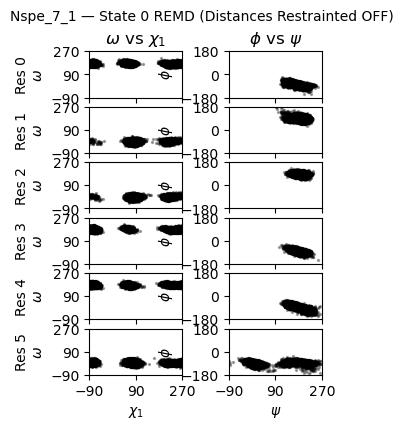

Plotting Cluster 7 with 1 frames


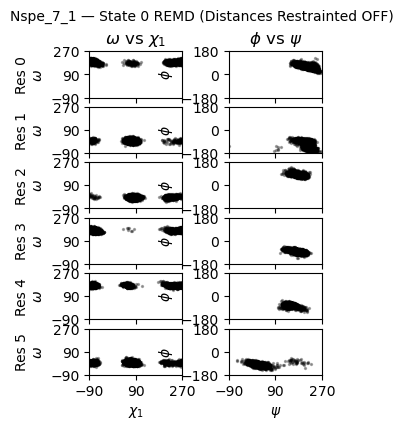

Plotting Cluster 0 with 1 frames


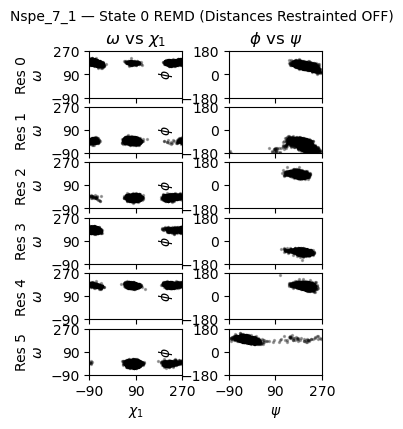

Plotting Cluster 10 with 1 frames


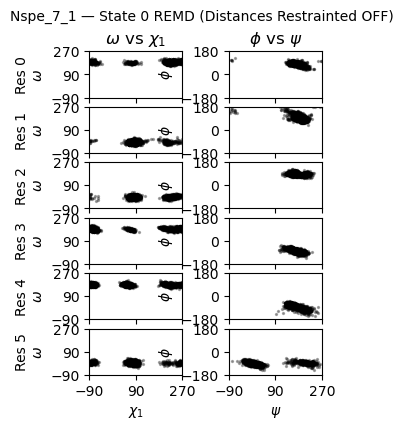

Plotting Cluster 15 with 1 frames


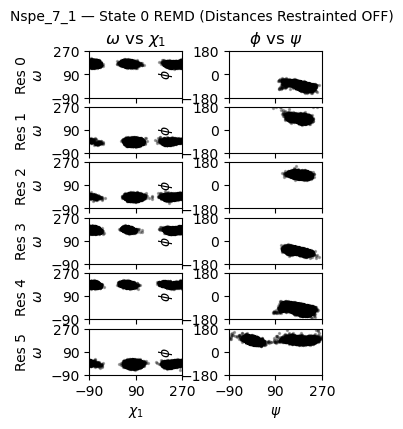

In [37]:
# Available options for angles_to_plot:

# "phi_psi"      # Plot ψ vs φ
# "omega_phi"    # Plot φ vs ω
# "omega_psi"    # Plot ψ vs ω
# "omega_chi1"   # Plot χ₁ vs ω
# "phi_chi1"     # Plot χ₁ vs φ
# "psi_chi1"     # Plot χ₁ vs ψ

residues_to_plot = np.arange(0, 24, 4).tolist()  # Modify if needed



angles_to_plot = ["omega_chi1", "phi_psi"]  # customize as needed

for label, indices in top_cluster.items():
    omega_input = omegas[indices, :][np.newaxis, ...]  # shape becomes (1, n_frames, 24)

    print(f"Plotting Cluster {label} with {omega_input.shape[0]} frames")

    plot_dihedral_quadruplets(
        omega_all=omega_input,
        residues_to_plot=residues_to_plot,
        states=[0],  # Only 1 cluster at a time
        use_latex=True,
        angles_to_plot=angles_to_plot
    )

## Sampling

In [38]:
# Define the directory path
directory = "sampling/"

# Check if the directory exists
if os.path.exists(directory):
    # Remove all contents of the directory
    shutil.rmtree(directory)
    # Recreate the empty directory
    os.makedirs(directory)
    print(f"All contents in '{directory}' have been cleared.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

All contents in 'sampling/' have been cleared.


In [39]:
sample_size = 5

# Filter cluster assignments: only those in top_labels
selected_clusters = [label for label in np.unique(assignments) if label in top_n]

# Create cluster and frame dictionaries for selected clusters
cluster = {label: [] for label in selected_clusters}
frames = {label: [] for label in selected_clusters}

# Store frame indices in each selected cluster
for index, assignment in enumerate(assignments):
    if assignment in selected_clusters:
        cluster[assignment].append(index)

# Sample frames only from selected clusters
for label in selected_clusters:
    if len(cluster[label]) > 0:
        sample_n = min(sample_size, len(cluster[label]))
        indices = np.random.choice(cluster[label], size=sample_n, replace=False)
        frames[label] = indices.tolist()

print('Sampled frames per selected cluster:', {k: len(v) for k, v in frames.items()})


Sampled frames per selected cluster: {0: 5, 7: 5, 9: 5, 10: 5, 15: 5}


In [40]:
# Load all trajectories and join
HREX_dir = '../traj_remd'
run_num = 10
trajs = []
HREX_list = [f"REMD_200ns_{i}" for i in range(1, run_num + 1)]

for HREX in HREX_list:
    HREX_path = f"{HREX_dir}/{HREX}"  
    xtcfile = f"{HREX_path}/state_0/HREMD.part0001_intact.xtc"
    grofile = f"../nspe_7_1.amb2gmx/nspe_7_1_GMX.gro"
    traj = md.load(xtcfile, top=grofile)
    trajs.append(traj)

# Concatenate all trajectories
concatenated_trajs = md.join(trajs)

# Save sampled frames for each selected cluster
for label in frames:
    sampling = concatenated_trajs[frames[label]]
    sampling.save_xtc(f"sampling/sample_state_0_cluster{label}.xtc")
    sampling.save_pdb(f"sampling/sample_state_0_cluster{label}.pdb")
